In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from nflows.transforms.normalization import ActNorm
from tqdm import tqdm
import torch.nn.functional as F

from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.riemannian_autoencoder.image.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackImageRiemannianAutoencoder
from src.transforms.multi_layer_parity_conv2d.tanh import MultiLayerTanhParityConv2DTransform
from src.transforms.parity_conv import ParityConv2DTransform

device = "cuda" if torch.cuda.is_available() else "cpu"


# Blur/noise settings
H, W = 14, 14
if H == 28:
    blur_kernel_size = 9
    blur_sigma = 1.5
    noise_sigma = 0.05
elif H == 14:
    blur_kernel_size = 5
    blur_sigma = 1.0
    noise_sigma = 0.05

folder_name = "mnist_deblur_h" + str(H) + "_w" + str(W) + "_blurkernelsize[" + str(blur_kernel_size) + "]_blursigma[" + str(blur_sigma) + "]_noisesigma[" + str(noise_sigma) + "]"
data_folder_path = os.path.join("data","MNIST","reconstructed",f"{folder_name}")
results_folder_path = os.path.join("results","mnist","pnp_raf",f"{folder_name}")

In [ ]:
# Plot original, noisy, and denoised images
def show_images(img_list, titles):
    fig, axes = plt.subplots(1, len(img_list), figsize=(12, 4))
    for i, (img, title) in enumerate(zip(img_list, titles)):
        axes[i].imshow(img[0].cpu().numpy().squeeze(), cmap="gray")
        axes[i].set_title(title)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

Total train: 55000 | Clean fixed: 100 | Unlabeled corrupted: 54900


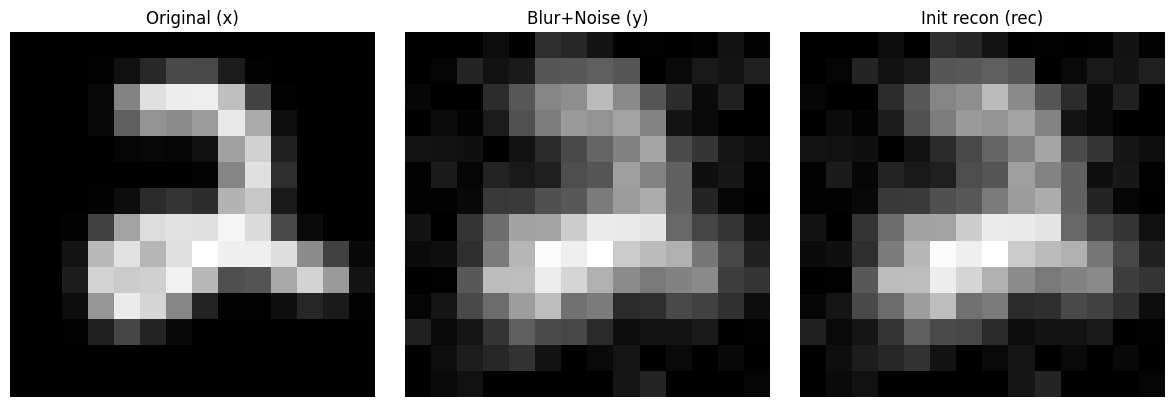

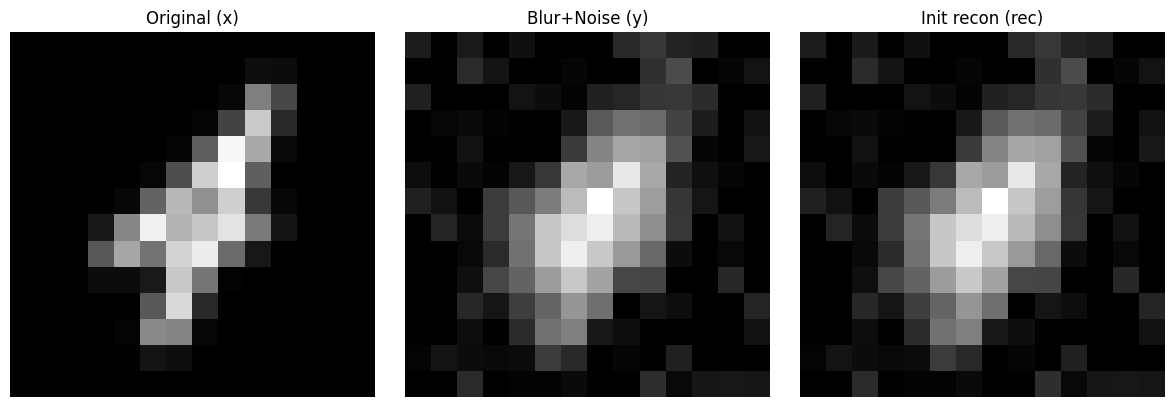

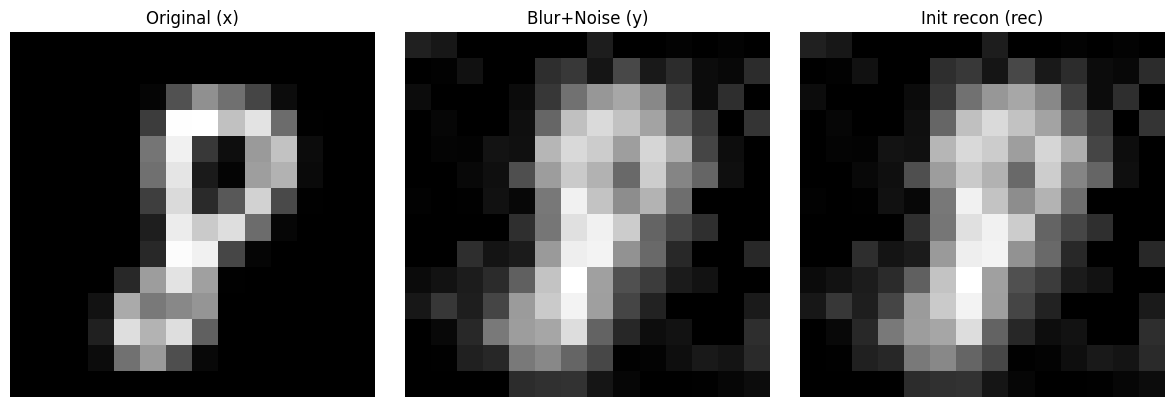

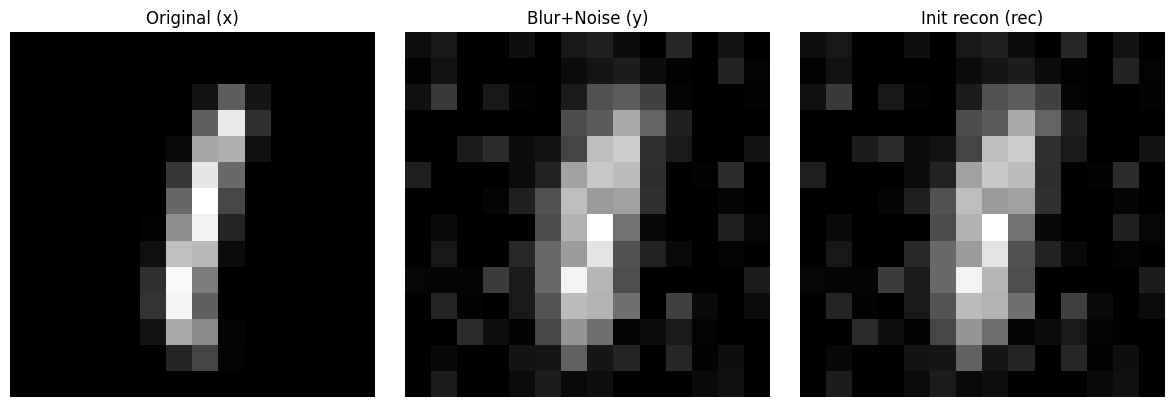

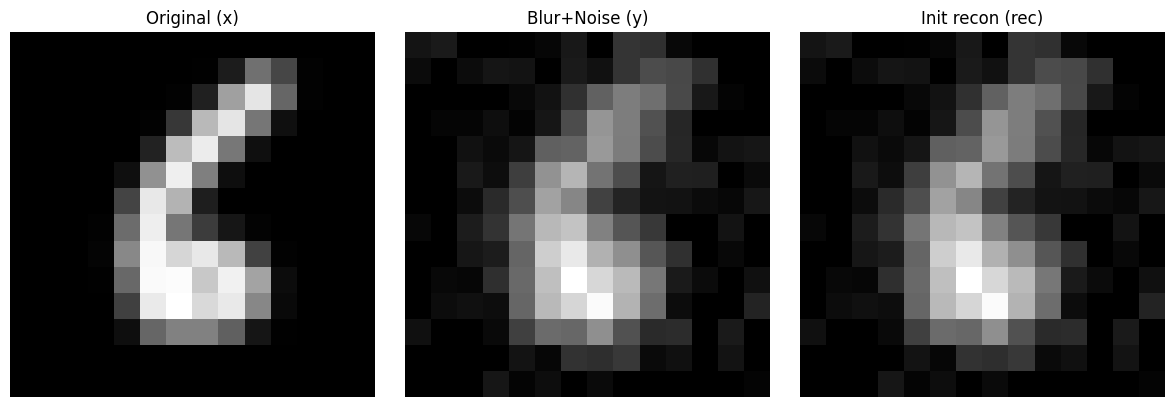

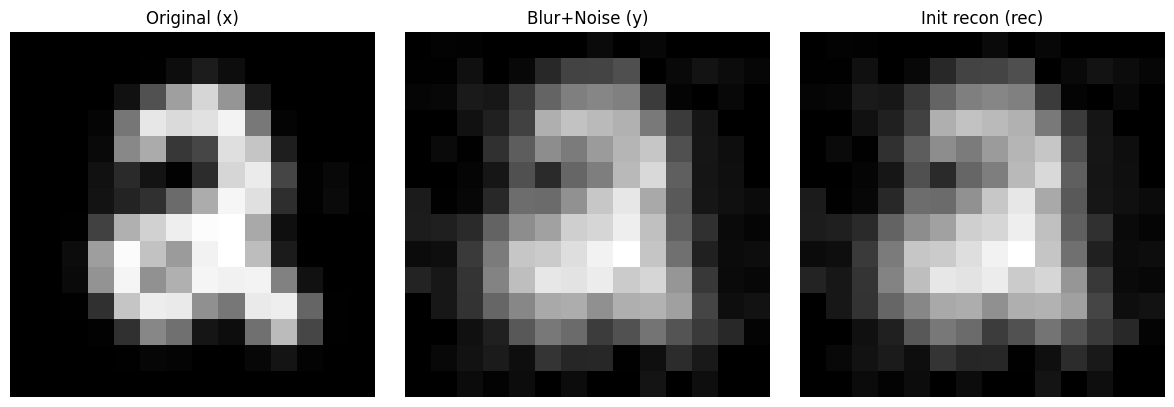

In [ ]:
# ----------------------------
# Load train data
# ----------------------------
num_train = 55000
batch_size = 250

def gaussian_kernel2d(kernel_size: int, sigma: float, device: str = "cpu"):
    """Returns a normalized 2D Gaussian kernel [1,1,k,k]."""
    ax = torch.arange(kernel_size, device=device) - (kernel_size - 1) / 2.0
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel.view(1, 1, kernel_size, kernel_size)

class BlurForward(nn.Module):
    """Fixed blur operator A: convolution with a fixed Gaussian kernel."""
    def __init__(self, kernel_size: int, sigma: float):
        super().__init__()
        k = gaussian_kernel2d(kernel_size, sigma, device="cpu")
        self.register_buffer("kernel", k)
        self.padding = kernel_size // 2

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.conv2d(x, self.kernel, padding=self.padding)

    def pseudo_inverse(self, y: torch.Tensor) -> torch.Tensor:
        return y

blur_op = BlurForward(blur_kernel_size, blur_sigma).to(device)

tfm = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
])

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)

mnist_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=False)

clean_batches = []
for x, _ in mnist_loader:
    clean_batches.append(x)
    if sum(b.shape[0] for b in clean_batches) >= num_train:
        break

clean_data_train = torch.cat(clean_batches, dim=0)[:num_train]  # [N,1,28,28]
clean_data_train = clean_data_train.to(device)

# Construct corrupted measurements: y = A x + noise
with torch.no_grad():
    cor_data_train = blur_op.forward(clean_data_train)
    cor_data_train = cor_data_train + noise_sigma * torch.randn_like(cor_data_train)
    cor_data_train = cor_data_train.clamp(0.0, 1.0)

with torch.no_grad():
    rec_data_train = blur_op.pseudo_inverse(cor_data_train)
    rec_data_train = rec_data_train.clamp(0.0, 1.0)

mask = torch.ones(1, 1, H, W, device=device)

# --------------------------------------------
# make a fixed-size clean subset
# --------------------------------------------
num_clean_fixed = 100
assert 0 < num_clean_fixed < num_train

gen = torch.Generator().manual_seed(1234)
perm = torch.randperm(num_train, generator=gen)
perm = perm.to(device)

idx_clean   = perm[:num_clean_fixed]
idx_corrupt = perm[num_clean_fixed:]

x_clean_small = clean_data_train[idx_clean]
y_corr_small  = cor_data_train[idx_clean]
y_corr_rest   = cor_data_train[idx_corrupt]

# --------------------------------------------
# Dataloaders
# --------------------------------------------
train_dataset = torch.utils.data.TensorDataset(cor_data_train.detach().cpu(), rec_data_train.detach().cpu())
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

clean_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_clean_small.detach().cpu()),
    batch_size=min(batch_size, len(x_clean_small)),
    shuffle=True,
    drop_last=True
)

labeled_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(y_corr_small.detach().cpu(), x_clean_small.detach().cpu()),
    batch_size=min(batch_size, len(x_clean_small)),
    shuffle=True,
    drop_last=True
)

unlabeled_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(y_corr_rest.detach().cpu()),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

print(f"Total train: {num_train} | Clean fixed: {len(x_clean_small)} | Unlabeled corrupted: {len(y_corr_rest)}")

# --------------------------------------------
# visualization
# --------------------------------------------
for i in range(6):
    show_images(
        [clean_data_train[i].detach().cpu(), cor_data_train[i].detach().cpu(), rec_data_train[i].detach().cpu()],
        ["Original (x)", "Blur+Noise (y)", "Init recon (rec)"]
    )

In [ ]:
class BlurForward(nn.Module):
    """
    Physics operator: y = A x + noise, with A = fixed blur convolution.
    """
    def __init__(self, kernel_size: int = 9, sigma: float = 1.5, pseudo_inverse_reg: float | None = None):
        super().__init__()
        self.kernel_size = int(kernel_size)
        self.sigma = float(sigma)
        self.lambd = pseudo_inverse_reg
        self.padding = self.kernel_size // 2

        k = gaussian_kernel2d(self.kernel_size, self.sigma, device=torch.device("cpu"))
        self.register_buffer("kernel", k)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.conv2d(x, self.kernel.to(x.device), padding=self.padding)

    def pseudo_inverse(self, y: torch.Tensor) -> torch.Tensor:
        if self.lambd is not None:
            return y / (1.0 + self.lambd)
        else:
            return y

### Learning Pullback Geometry ###

In [ ]:
def create_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
    base_dist = distributions.StandardNormal(shape=[in_channels, height, width])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
    transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return NFlowImageDiffeomorphism(1, height, width, flows.Flow(transform=flow_transforms, distribution=base_dist))

In [ ]:
class CNN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int):
        super().__init__()
        layers = []
        layers.append(nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(hidden_channels, in_channels, kernel_size=3, padding=1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DualOutputNet(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int):
        super().__init__()
        self.cnn = CNN(in_channels, hidden_channels)

    def forward(self, x):
        cnn_out = self.cnn(x)
        out = torch.cat([x, cnn_out], dim=-1)
        return out

In [ ]:
# define the conditional normalizing flow model
def create_conditional_distribution_model(in_channels, height, width, hidden_channels):
    context_encoder = DualOutputNet(in_channels, hidden_channels)
    return distributions.ConditionalDiagonalNormal(shape=[in_channels, height, width], context_encoder=context_encoder)

In [ ]:
from src.inverse_problems import InverseProblem
import math
class RiemannianAmbientFlowProblem(InverseProblem):
    """

    Loss(y; λ_clean) =
      - E_b [ logmeanexp_k ( log p(y|x_k) + log p_phi(x_k) - log q(x_k | y) ) ]  +  λ_clean * ( - E[ log p_phi(x_clean) ] )

    where x_k ~ q(·|y), p_phi is the learned prior flow, and q is the amortized posterior (ConditionalDiagonalNormal or similar).
    """
    def __init__(self, forward_operator, prior_nflow_diffeomorphism, posterior_distribution,
                 noise_level, num_samples=10, low_rank_reg_param=None):
        super().__init__(prior_nflow_diffeomorphism.d, forward_operator)
        self.phi_prior = prior_nflow_diffeomorphism
        self.p_post    = posterior_distribution
        self.sigma     = float(noise_level)
        self.M         = int(num_samples)
        self.mu        = low_rank_reg_param

    @staticmethod
    def _flatten_img(x):
        return x.view(x.shape[0], -1)

    @staticmethod
    def _logmeanexp(logw, dim=1):
        m = logw.max(dim=dim, keepdim=True).values
        return m + torch.log(torch.mean(torch.exp(logw - m), dim=dim, keepdim=True).clamp_min(1e-30))

    def _loglik_masked_gaussian(self, y, Ax):
        resid2 = (Ax - y).pow(2).flatten(start_dim=-3).sum(dim=-1)  # [B, M]
        return -0.5 * resid2 / (self.sigma * self.sigma)

    def reconstruction_loss(self, y, x_pnp, x_clean=None, lambda_clean: float = 0.0):
        B = y.shape[0]

        x_samp = self.p_post.sample(self.M, context=y)

        if x_samp.dim() == 5 and x_samp.shape[0] == B:
            x_samp = x_samp.permute(1, 0, 2, 3, 4)
        elif x_samp.dim() != 5:
            raise RuntimeError(f"Expected 5D tensor from posterior sampling, got shape {tuple(x_samp.shape)}")

        M, B2, C, H, W = x_samp.shape
        assert B2 == B

        x_flat = x_samp.reshape(M * B, C, H, W)
        y_flat = y.unsqueeze(0).expand(M, B, C, H, W).reshape(M * B, C, H, W)

        log_p_prior_flat = self.phi_prior.nflow.log_prob(x_flat)  # [M*B]
        resid = self.forward_operator.forward(x_flat) - y_flat     # [M*B,C,H,W]
        log_p_noise_flat = -(resid.pow(2) / (2 * self.sigma**2)).sum(dim=(1,2,3))  # [M*B]
        log_p_post_flat  = self.p_post.log_prob(x_flat, context=y_flat)            # [M*B]

        # Unfold back to [M,B]
        logw = (log_p_prior_flat + log_p_noise_flat - log_p_post_flat).view(M, B)

        loss_rec = -(torch.logsumexp(logw, dim=0) - math.log(M)).mean()

        # ----- Optional: prior MLE on clean subset -----
        loss_clean = torch.zeros((), device=y.device)
        if (x_clean is not None) and (lambda_clean > 0.0):
            loss_clean = -self.phi_prior.nflow.log_prob(x_clean.to(y.device)).mean()

        loss = loss_rec + lambda_clean * loss_clean

        # Regularization
        if self.mu is not None:
            D_0_phi_inv = self.phi_prior.adjoint_differential_inverse(torch.zeros(self.d, self.d, device=y.device).reshape(self.d, *x_reconstructed.shape[1:]),
                                                                    torch.eye(self.d, self.d, device=y.device).reshape(self.d, *x_reconstructed.shape[1:])
                                                                    ).reshape(self.d, self.d)
            loss += self.mu * torch.linalg.norm(D_0_phi_inv, ord='fro')

        return loss

In [ ]:
forward = BlurForward(
    kernel_size=blur_kernel_size,
    sigma=blur_sigma,
    pseudo_inverse_reg=0.1
).to(device)

L = 64
K = 5
order = 2
n_flows = 16
prior_nflow_diffeo = create_flow_model(1, H, W, K, L, order, n_flows)

M = 8
posterior_dist = create_conditional_distribution_model(1, H, W, M)

noise_level = noise_sigma
low_rank_reg_param = None
model = RiemannianAmbientFlowProblem(forward, prior_nflow_diffeo, posterior_dist, noise_level, low_rank_reg_param=low_rank_reg_param).to(device)

lr = 1e-3
lam_clean = 100.0
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
def _save_prior_samples(model, save_dir: str, epoch: int, n_samples: int = 10):
    model.eval()
    with torch.no_grad():
        x_prior_samples = model.phi_prior.nflow.sample(n_samples).detach()

    fig, axes = plt.subplots(1, n_samples, figsize=(2 * n_samples, 2.5))
    if n_samples == 1:
        axes = [axes]
    for i in range(n_samples):
        axes[i].imshow(x_prior_samples[i].cpu().squeeze(), cmap="gray")
        axes[i].axis("off")

    plt.tight_layout()

    os.makedirs(save_dir, exist_ok=True)
    out_path = os.path.join(save_dir, f"prior_samples_epoch_{epoch+1:04d}.png")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    return out_path

In [ ]:
def train(
    model,
    unlabeled_train_loader,           # DataLoader(TensorDataset(y_corr)), shape [B,1,28,28]
    pnp_loader,
    clean_loader=None,                # DataLoader(TensorDataset(x_clean)) or None
    optimizer=None,
    n_epochs=100,
    save_dir=".",
    start_epoch=0,
    lambda_clean=1.0,                 # weight on clean MLE term
    use_amp=False,                     # mixed precision optional
    n_sample_images=10
):
    assert optimizer is not None, "Pass an optimizer."
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_loss = float("inf")
    model.train()

    clean_iter = iter(clean_loader) if clean_loader is not None else None
    img_dir = os.path.join(save_dir, "images")
    sample_every = 2
    os.makedirs(img_dir, exist_ok=True)

    for epoch in range(start_epoch, n_epochs):
        model.train()
        running_loss = 0.0
        n_steps = 0

        pbar = tqdm(unlabeled_train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
        for (y_batch, ) in pbar:
            y_batch = y_batch.to(device)

            x_clean_batch = None
            lam = 0.0
            if clean_iter is not None and lambda_clean > 0.0:
                try:
                    (x_clean_batch,) = next(clean_iter)
                except StopIteration:
                    clean_iter = iter(clean_loader)
                    (x_clean_batch,) = next(clean_iter)
                x_clean_batch = x_clean_batch.to(device)
                lam = lambda_clean

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast():
                    loss = model.reconstruction_loss(y_batch, None, x_clean=x_clean_batch, lambda_clean=lam)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss = model.reconstruction_loss(y_batch, None, x_clean=x_clean_batch, lambda_clean=lam)
                loss.backward()
                optimizer.step()

            running_loss += float(loss.detach().item())
            n_steps += 1
            pbar.set_postfix(loss=f"{running_loss / n_steps:.4f}")

        avg_epoch_loss = running_loss / max(1, n_steps)
        print(f"Epoch {epoch+1}/{n_epochs} | avg_loss = {avg_epoch_loss:.4f}")

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "avg_loss": avg_epoch_loss,
            "best_loss": best_loss,
        }

        if (epoch + 1) % sample_every == 0:
            path = os.path.join(save_dir, f"epoch_{epoch+1}_model.pth")
            torch.save(checkpoint, path)
            print(f"Saved checkpoint: {path}")

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            checkpoint["best_loss"] = best_loss
            torch.save(checkpoint, os.path.join(save_dir, "best_model.pth"))

        if sample_every is not None and sample_every > 0 and ((epoch + 1) % sample_every == 0):
            out_path = _save_prior_samples(
                model=model,
                save_dir=img_dir,
                epoch=epoch,
                n_samples=n_sample_images,
            )
            print(f"Saved prior samples: {out_path}")

    print(f"Training completed. Best avg_loss: {best_loss:.4f}")

In [ ]:
n_epochs = 400

checkpoint_dir = os.path.join(
    results_folder_path,
    f"checkpoints_latent_dim{L}_kernel_size{K}_order{order}_n_flows{n_flows}_"
    f"ntrain[{num_train}]_num_clean_imgs[{num_clean_fixed}]_lr[{lr}]"
)
if low_rank_reg_param is not None:
    checkpoint_dir += f"_lowrankreg[{low_rank_reg_param}]"

os.makedirs(checkpoint_dir, exist_ok=True)
print("Checkpoint directory:", checkpoint_dir)

train_model = False
if train_model:
    start_epoch = 0
    best_loss = float("inf")

    latest_checkpoints = [f for f in os.listdir(checkpoint_dir) if f.startswith("epoch_")]
    latest_checkpoint = max(latest_checkpoints, key=lambda x: int(x.split("_")[1])) if latest_checkpoints else None
    print("Latest checkpoint:", latest_checkpoint)

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        ckpt = torch.load(os.path.join(checkpoint_dir, latest_checkpoint), map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        start_epoch = ckpt["epoch"] + 1
        best_loss = ckpt.get("best_loss", best_loss)

    train(
        model=model,
        unlabeled_train_loader=unlabeled_train_loader,
        pnp_loader=labeled_train_loader,
        clean_loader=clean_loader,
        optimizer=optimizer,
        n_epochs=n_epochs,
        save_dir=checkpoint_dir,
        start_epoch=start_epoch,
        lambda_clean=lam_clean,
        use_amp=False,
        n_sample_images=10
    )

else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    ckpt = torch.load(best_model_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

model.eval()

Checkpoint directory: results/mnist/pnp_raf/mnist_deblur_h14_w14_blurkernelsize[5]_blursigma[1.0]_noisesigma[0.05]/checkpoints_latent_dim64_kernel_size5_order2_n_flows16_ntrain[55000]_num_clean_imgs[100]_lr[0.001]


PnPRiemannianAmbientFlowProblem(
  (forward_operator): BlurForward()
  (phi_prior): NFlowImageDiffeomorphism(
    (nflow): Flow(
      (_transform): CompositeTransform(
        (_transforms): ModuleList(
          (0): ActNorm()
          (1-2): 2 x ParityConv2DTransform(
            (conv2d): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
          )
          (3): MultiLayerTanhParityConv2DTransform(
            (cnn): Sequential(
              (0): MaskedConv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
              (1): TanhActivation()
              (2): MaskedConv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
              (3): TanhActivation()
              (4): MaskedConv2d(64, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            )
          )
          (4): ActNorm()
          (5-6): 2 x ParityConv2DTransform(
            (conv2d): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False

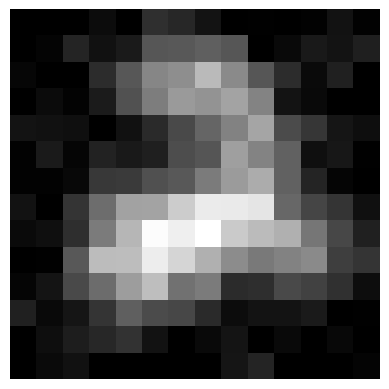

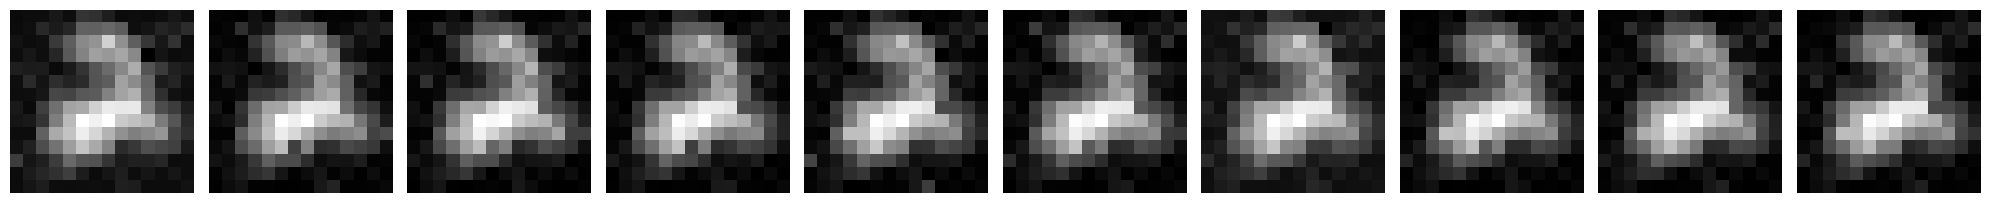

In [ ]:
x_reconstructed = model.p_post.sample(10, context=cor_data_train[0][None].to(device))[0].detach()

plt.imshow(rec_data_train[0].cpu().squeeze(), cmap="gray")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    axes[i].imshow(x_reconstructed[i].cpu().squeeze(), cmap="gray")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

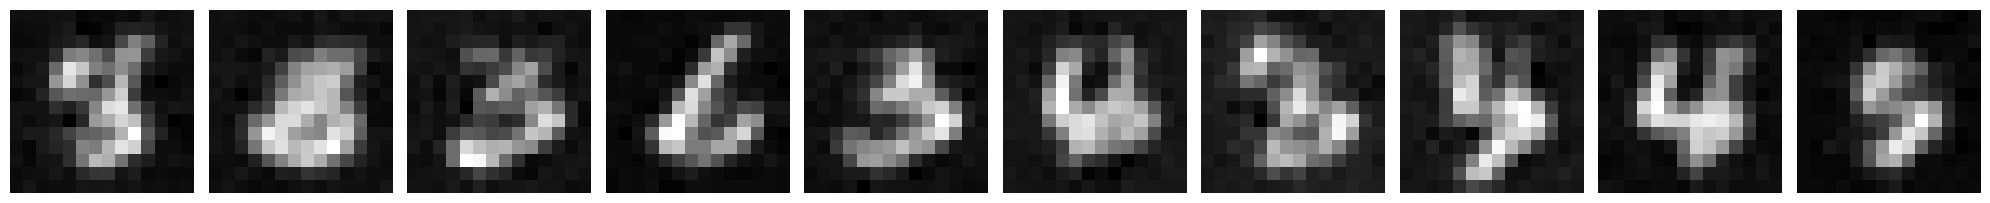

In [ ]:
x_prior_samples = model.phi_prior.nflow.sample(10).detach()

fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    axes[i].imshow(x_prior_samples[i].cpu().squeeze(), cmap="gray")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

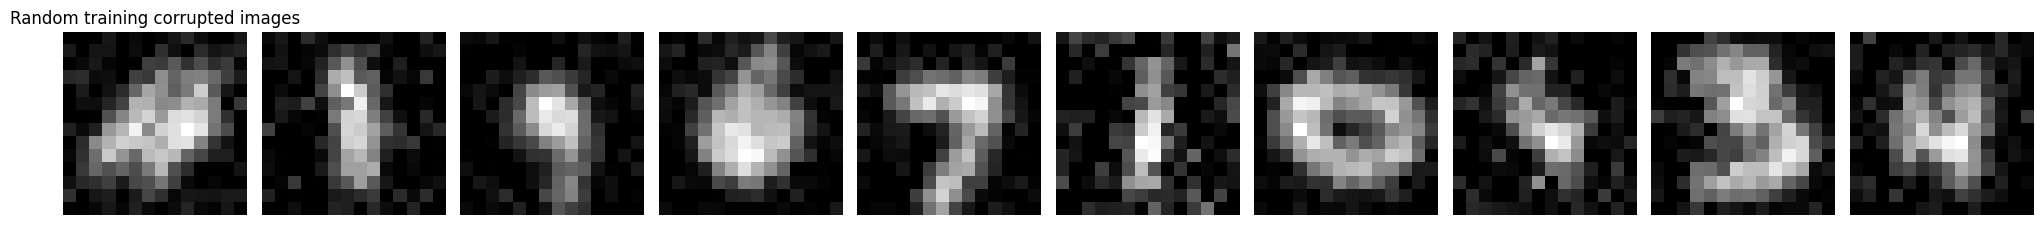

In [ ]:
num_show = 10
idx = torch.randperm(cor_data_train.shape[0])[:num_show]

x_cor_samples = cor_data_train[idx]

fig, axes = plt.subplots(1, num_show, figsize=(20, 4))
for i in range(num_show):
    axes[i].imshow(x_cor_samples[i].cpu().squeeze(), cmap="gray")
    axes[i].axis("off")
axes[0].set_title("Random training corrupted images", fontsize=12)
plt.tight_layout()
plt.show()

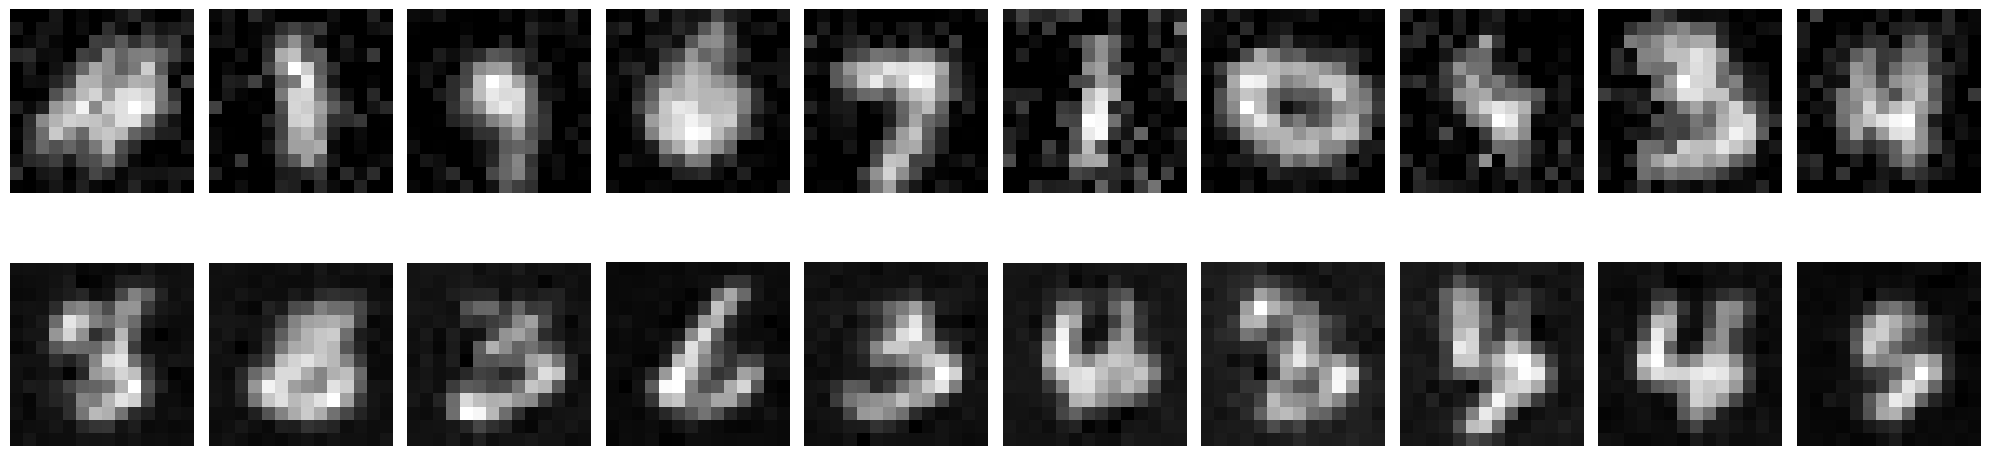

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 6))

for i in range(10):
    axes[0, i].imshow(x_cor_samples[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_prior_samples[i].cpu().squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Corrupted train", fontsize=12)
axes[1, 0].set_ylabel("Prior samples", fontsize=12)

plt.tight_layout()
plt.show()

### Evaluating Pullback Geometry ###

In [ ]:
manifold = StandardPullbackImageEuclidean(model.phi_prior)

In [ ]:
num_points = 10
num_geodesics = 5
t = torch.linspace(0., 1., num_points).to(device)

clean_geodesics = torch.zeros(num_geodesics, num_points, 1, H, W)

for i in range(num_geodesics):
    clean_geodesics[i] = manifold.geodesic(clean_data_train[i].to(device), clean_data_train[i+num_geodesics].to(device), t).detach().cpu()

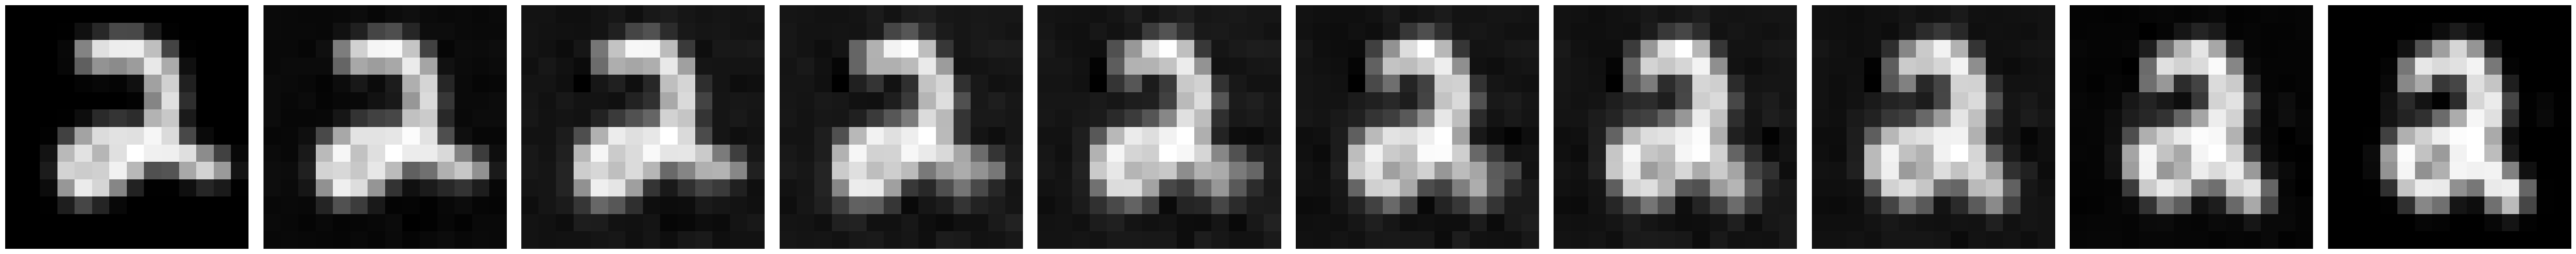

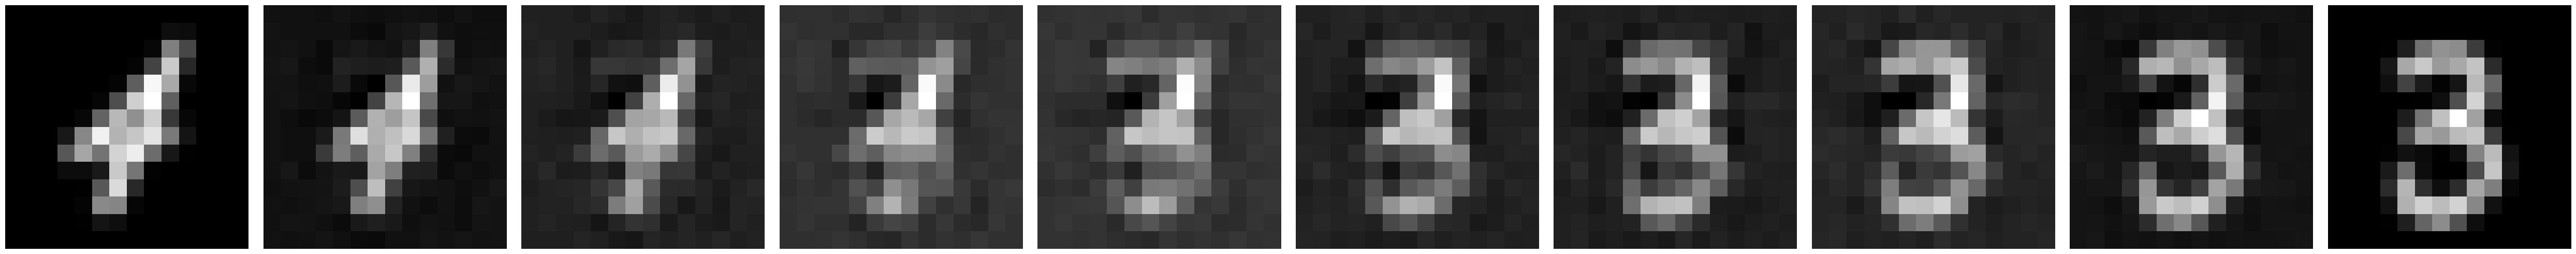

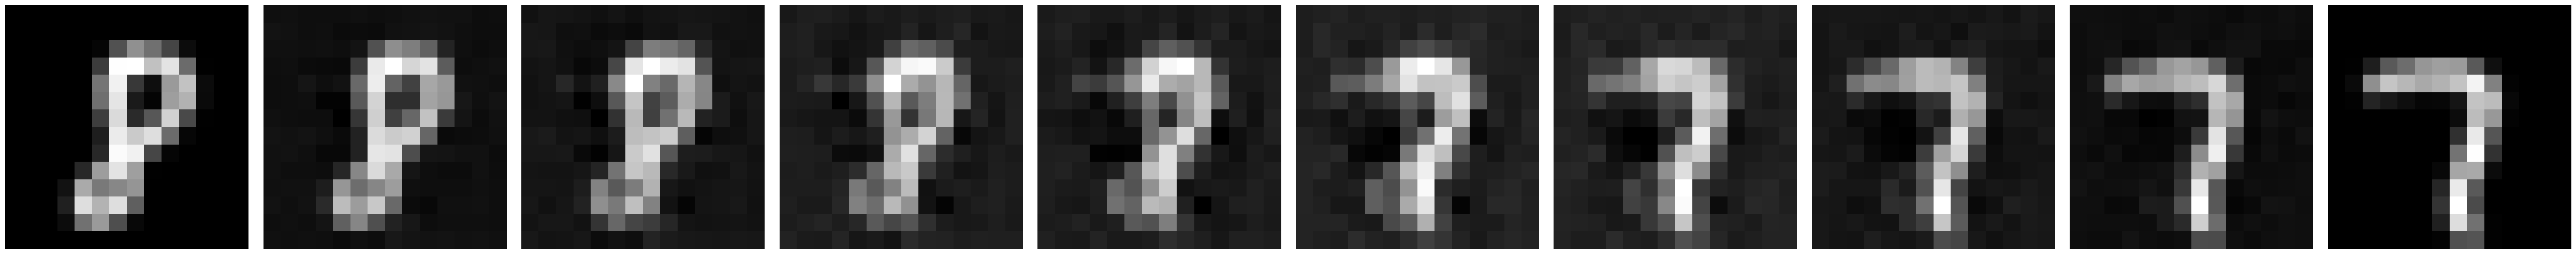

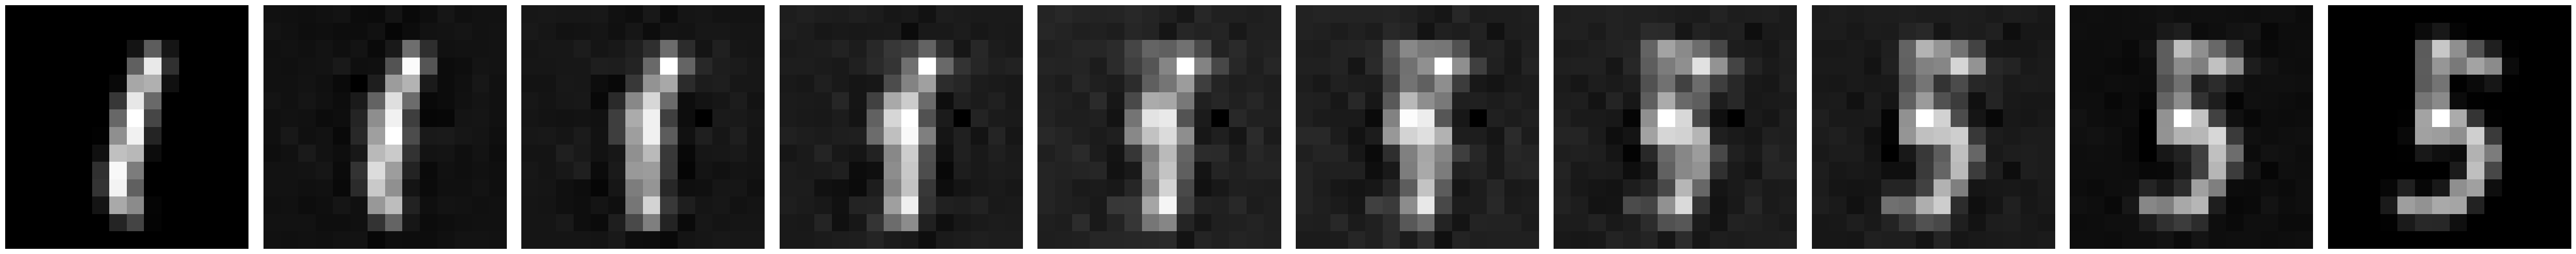

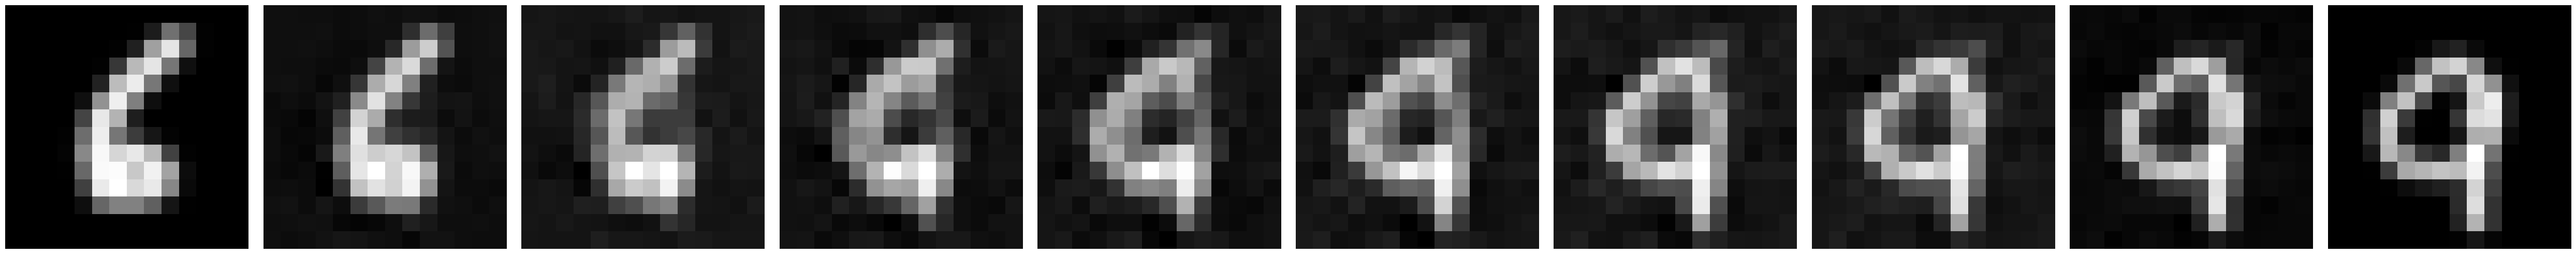

In [ ]:
for i in range(num_geodesics):
    fig, axes = plt.subplots(1,num_points, figsize=(5*num_points, 5))
    for j in range(num_points):
        axes[j].imshow(clean_geodesics[i, j].squeeze(), cmap='gray')
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
data_type = "clean_plus_prior" # "prior_samples", "post_samples"
if data_type == "clean_data":
    dps_for_RAE = x_clean_small.to(device)
elif data_type == "prior_samples":
    dps_for_RAE = model.phi_prior.nflow.sample(400).detach()
elif data_type == "post_samples":
    dps_for_RAE = torch.zeros((400, 1, H, W), device=device)
    for i in range(400):
        dps_for_RAE[i] = model.p_post.sample(1, context=cor_data_train[i][None].to(device))[0].detach()
elif data_type == "clean_plus_prior":
    n_clean = x_clean_small.shape[0]
    dps_for_RAE = torch.zeros((400 + n_clean, 1, H, W), device=device)
    dps_for_RAE[:n_clean,:,:,:] = x_clean_small.to(device)
    dps_for_RAE[n_clean:,:,:,:] = model.phi_prior.nflow.sample(400).detach().to(device)

### Construct RAE ###

In [ ]:
rec_bary = manifold.barycentre(dps_for_RAE).detach().cpu()

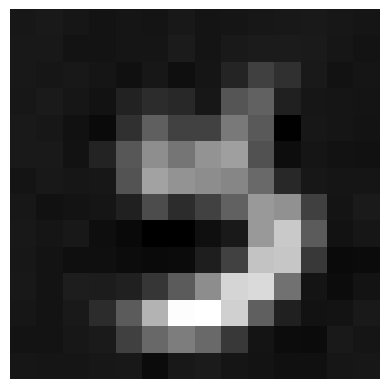

In [ ]:
plt.imshow(rec_bary.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
latent_dim = 40
rae = l2TangentSpacePCAPullbackImageRiemannianAutoencoder(manifold, dps_for_RAE, latent_dim)

constructed a Riemannian autoencoder with latent dimension = 40 and effectice eps = 0.042566657066345215


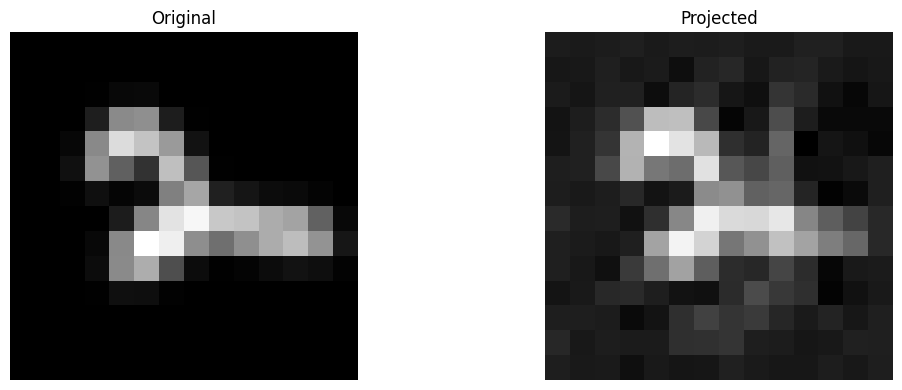

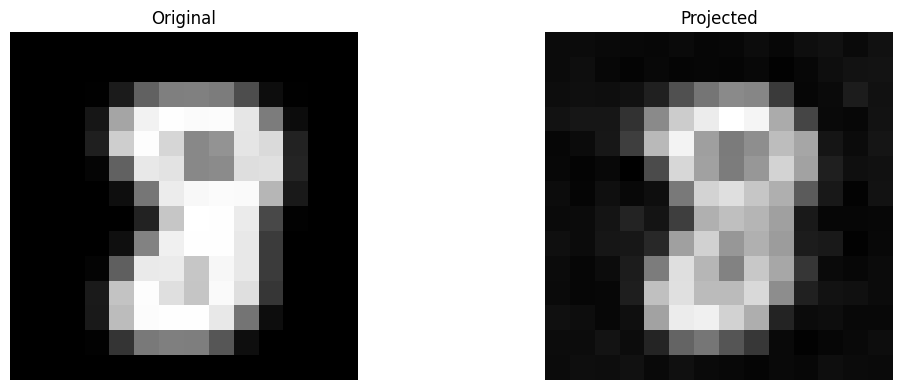

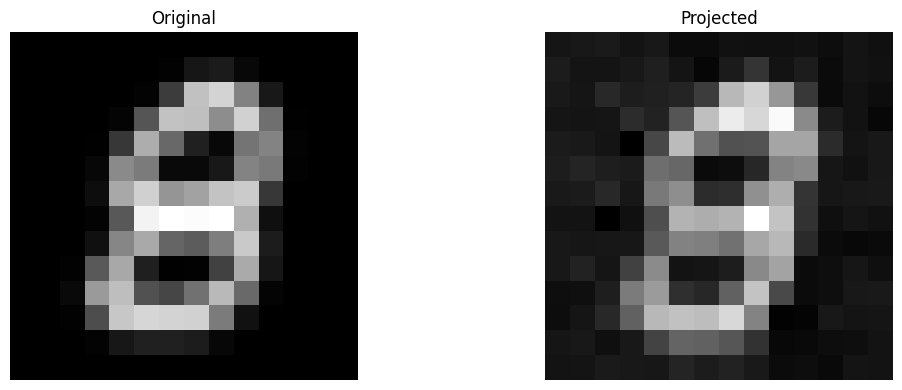

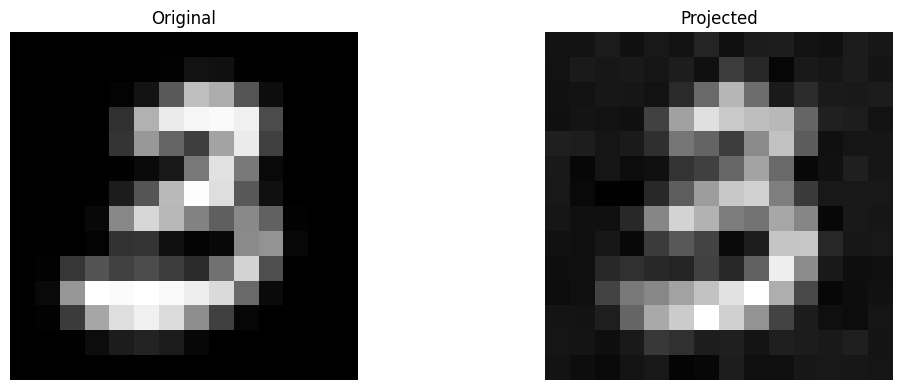

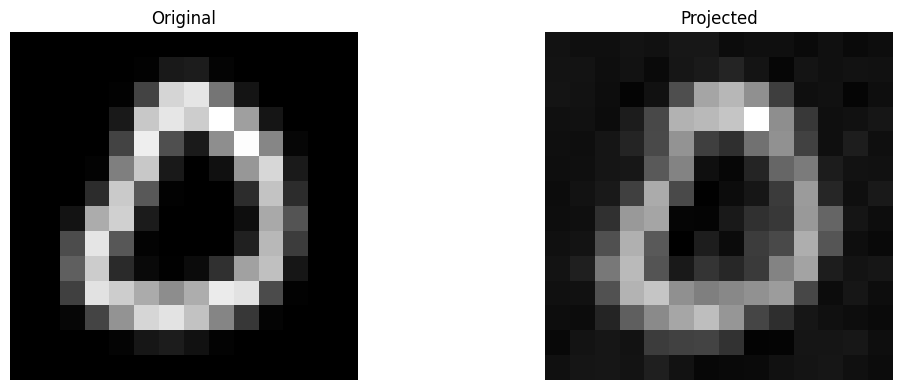

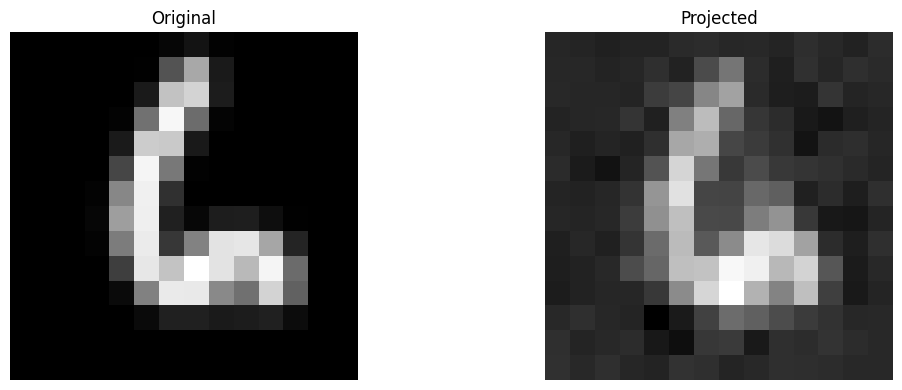

In [ ]:
projections = rae.project_on_manifold(x_clean_small[:6]).detach().cpu()

for i in range(6):
    show_images(
        [x_clean_small[i], projections[i].cpu()],
        ["Original", "Projected"]
    )

### Reconstruct over a Learned Data Manifold ###

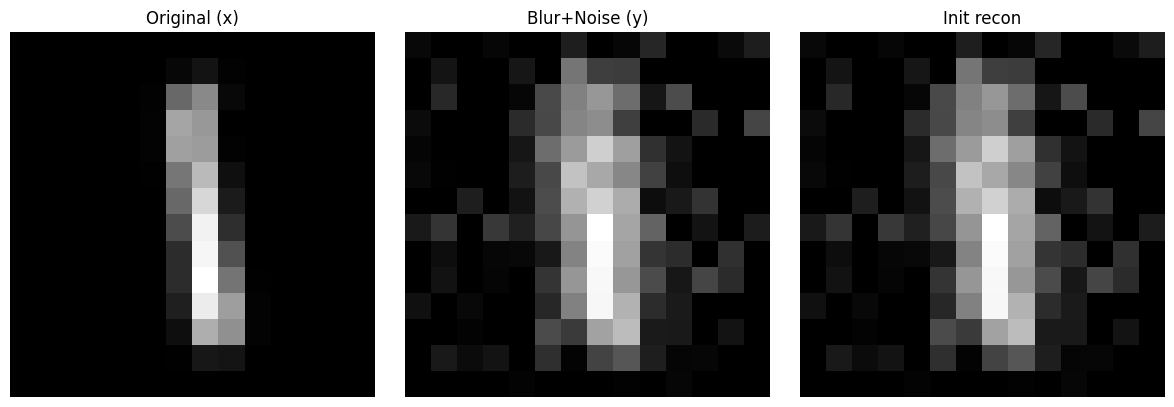

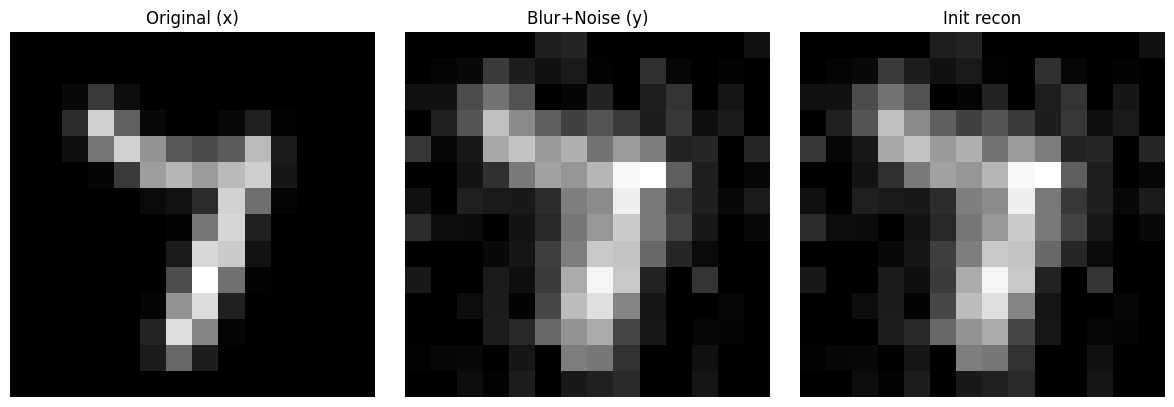

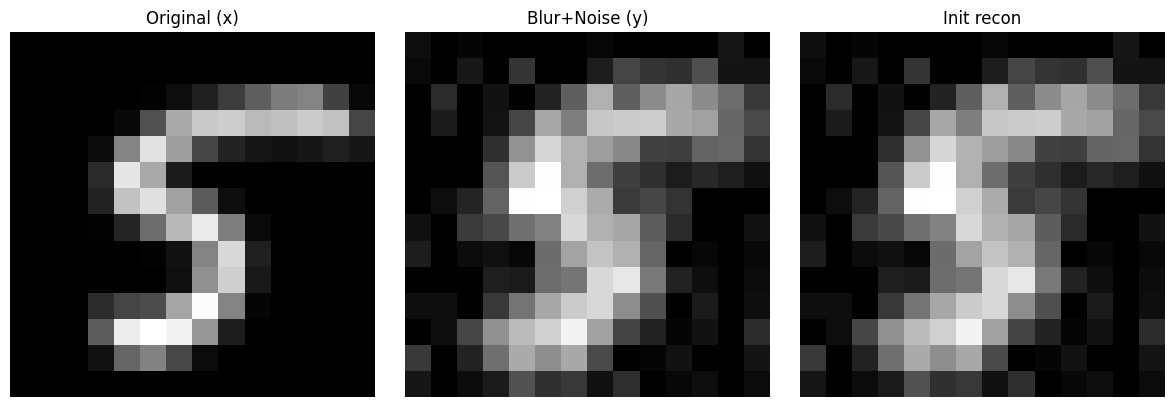

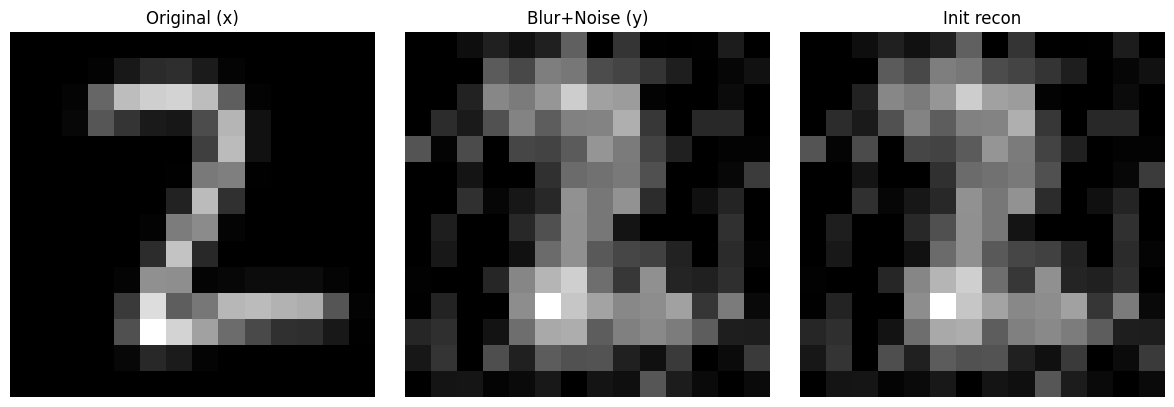

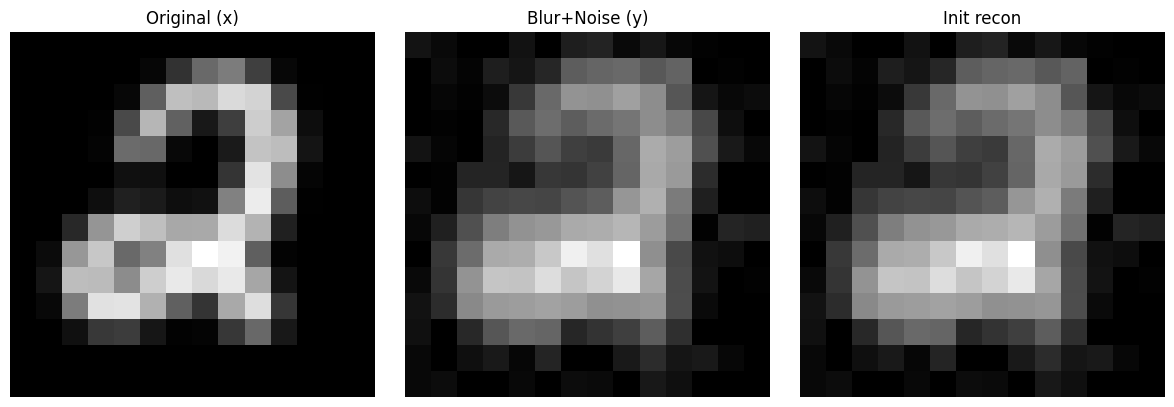

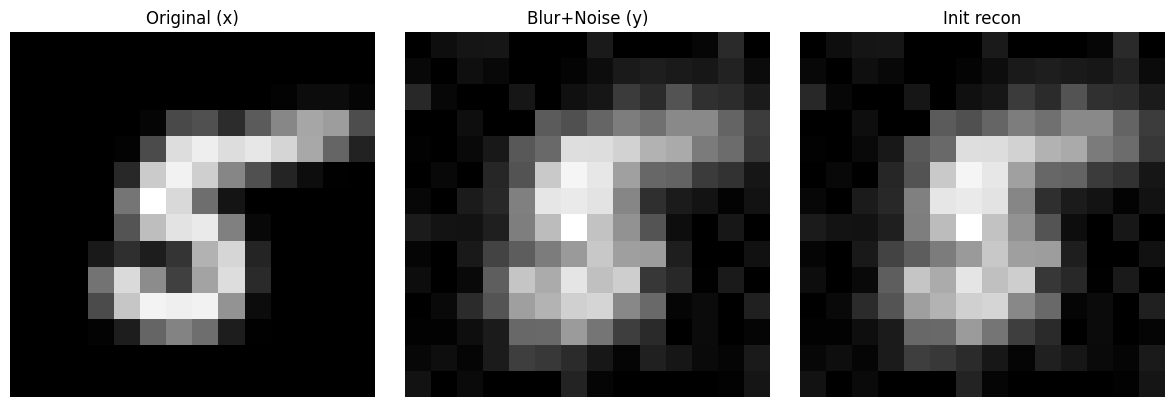


Building RAE from data_type='clean_data_plus_prior' (latent_dim=40, n_rae=400)
constructed a Riemannian autoencoder with latent dimension = 40 and effectice eps = 0.042542390525341034
Solving inverse problem on validation set with RAE built from 'clean_data_plus_prior'...
[batch val] it    0  meas-loss=2.3826e-02  recon-mse mean=6.2087e-02  med=5.9234e-02
[batch val] it  100  meas-loss=2.7398e-03  recon-mse mean=1.1242e-02  med=8.0792e-03
[batch val] it  200  meas-loss=2.3367e-03  recon-mse mean=9.3886e-03  med=7.3261e-03
[batch val] it  300  meas-loss=2.2226e-03  recon-mse mean=8.8028e-03  med=6.9668e-03
[batch val] it  400  meas-loss=2.1332e-03  recon-mse mean=8.3698e-03  med=6.9059e-03
[batch val] it  500  meas-loss=2.0880e-03  recon-mse mean=8.0889e-03  med=6.9059e-03
[batch val] it  600  meas-loss=2.0488e-03  recon-mse mean=7.8276e-03  med=6.9059e-03
[batch val] it  700  meas-loss=2.0286e-03  recon-mse mean=7.6694e-03  med=6.8719e-03
[batch val] it  800  meas-loss=2.0117e-03  rec

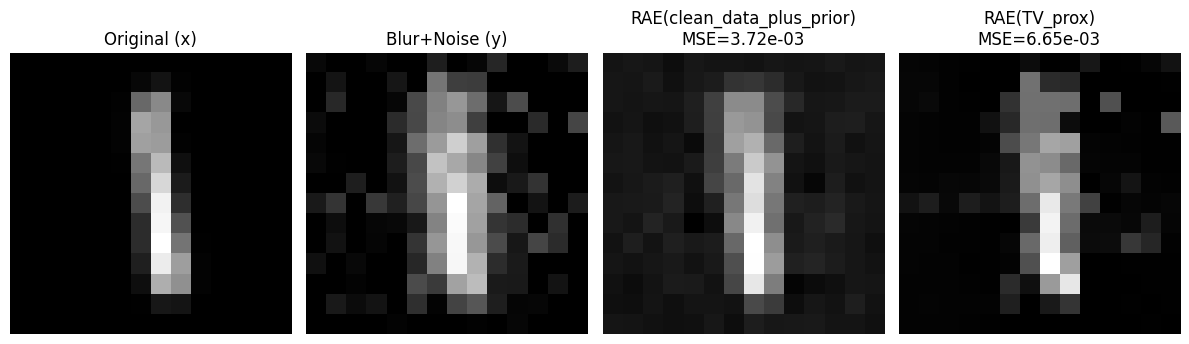

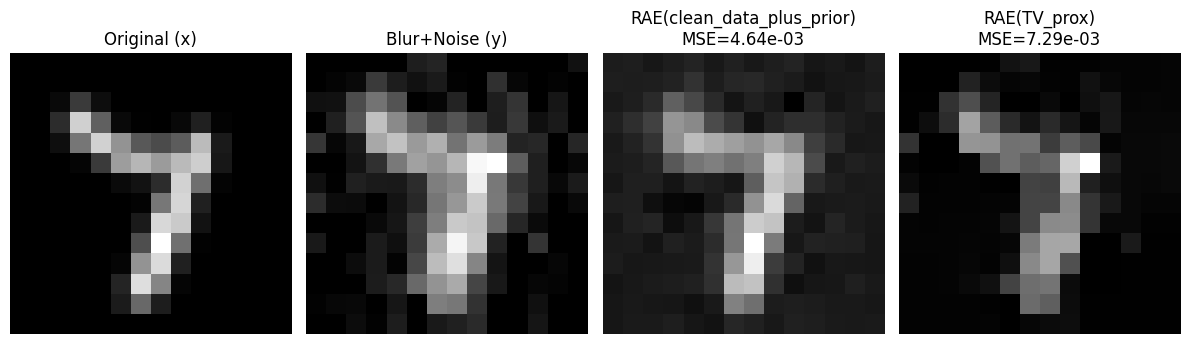

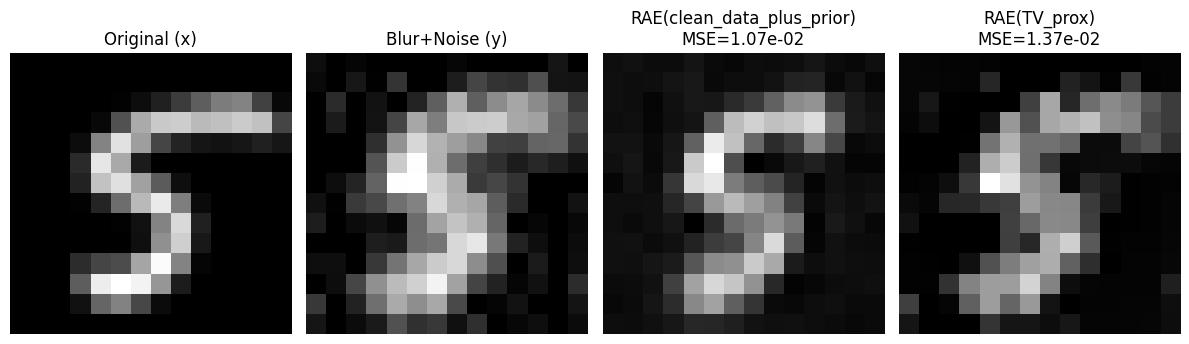

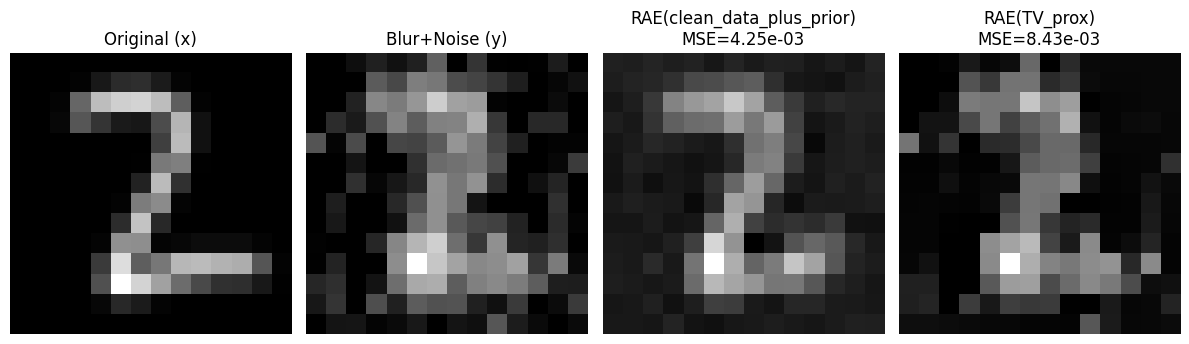

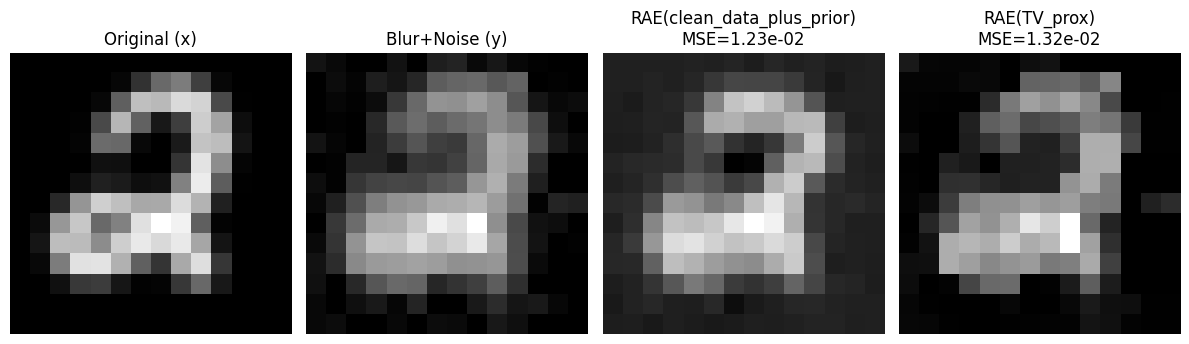

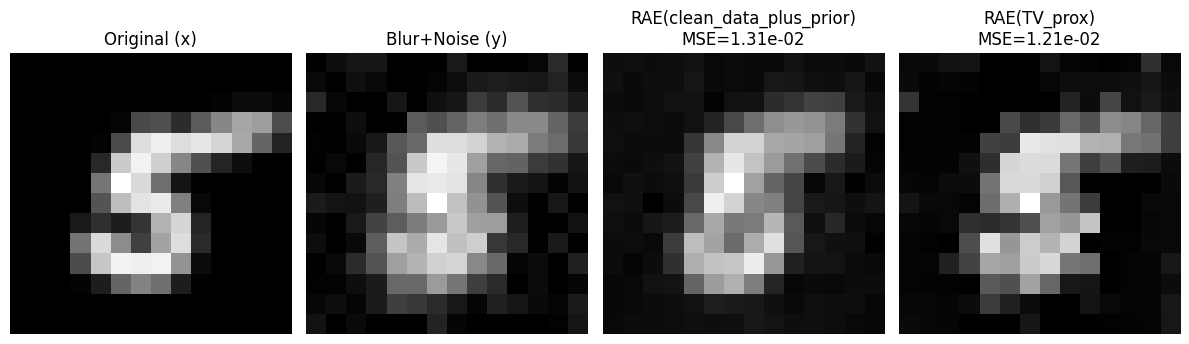

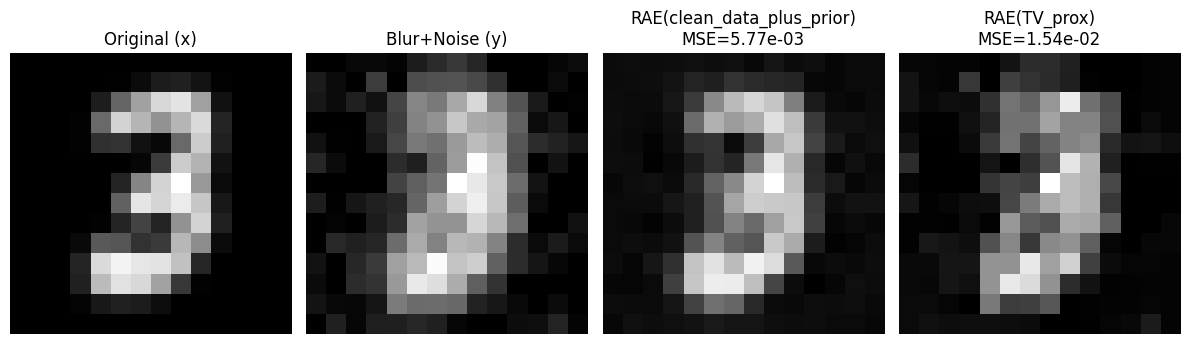

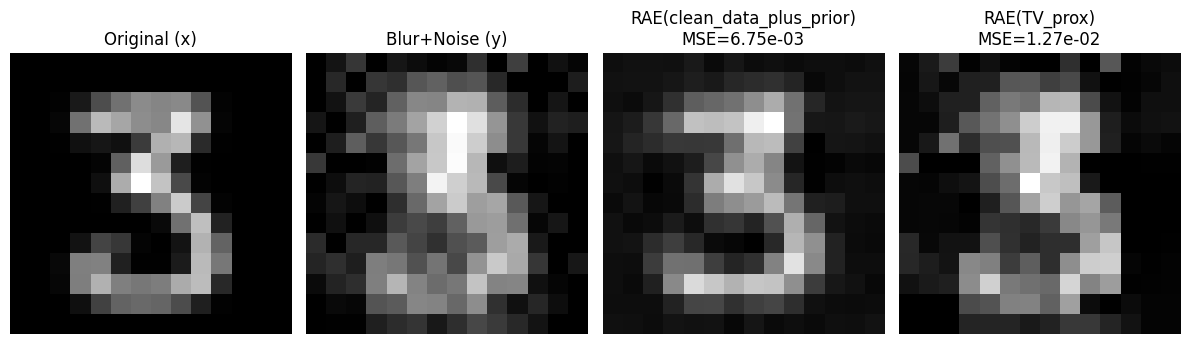

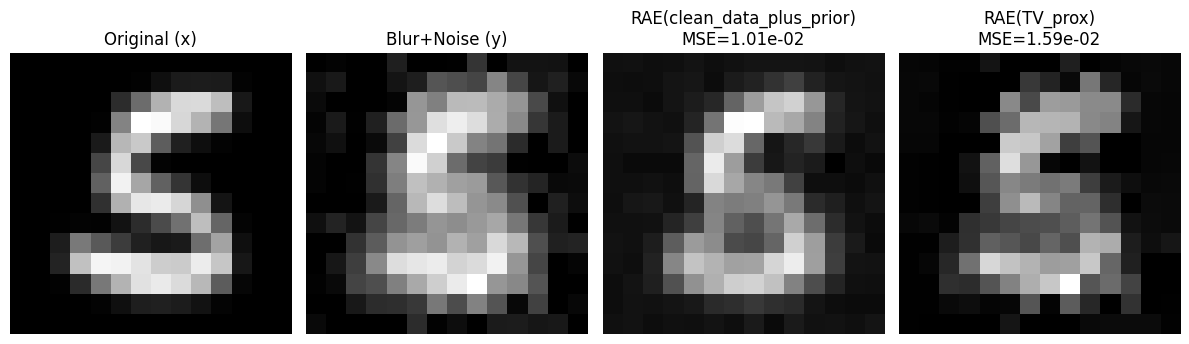

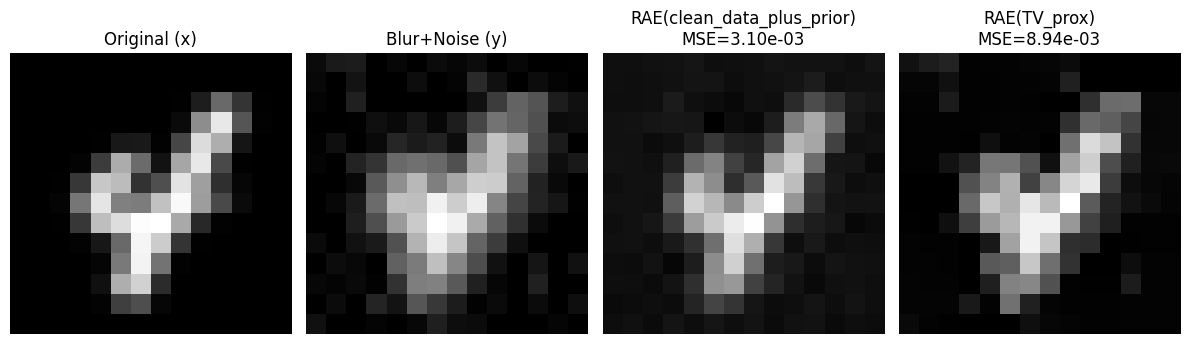

In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from skimage.restoration import denoise_tv_chambolle


num_val = 10
val_noise_sigma = noise_sigma  # reuse same noise level as training

mnist_val = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)
val_loader = DataLoader(mnist_val, batch_size=num_val, shuffle=True, drop_last=True)

clean_data_val, _ = next(iter(val_loader))
clean_data_val = clean_data_val.to(device)

with torch.no_grad():
    cor_data_val = forward(clean_data_val)
    cor_data_val = cor_data_val + val_noise_sigma * torch.randn_like(cor_data_val)
    cor_data_val = cor_data_val.clamp(0.0, 1.0)

    rec_data_val = forward.pseudo_inverse(cor_data_val).clamp(0.0, 1.0)

for i in range(min(6, num_val)):
    show_images(
        [clean_data_val[i].detach().cpu(), cor_data_val[i].detach().cpu(), rec_data_val[i].detach().cpu()],
        ["Original (x)", "Blur+Noise (y)", "Init recon"]
    )


def _apply_A(forward, x):
    return forward(x)

def _apply_At(forward, z):
    """
    Try to apply the true adjoint A^T if the operator provides it.
    Fallbacks:
      - forward.adjoint(z)
      - forward.transpose(z)
      - forward.pseudo_inverse(z)   (approx; not true adjoint)
    """
    if hasattr(forward, "adjoint") and callable(getattr(forward, "adjoint")):
        return forward.adjoint(z)
    if hasattr(forward, "transpose") and callable(getattr(forward, "transpose")):
        return forward.transpose(z)
    if hasattr(forward, "pseudo_inverse") and callable(getattr(forward, "pseudo_inverse")):
        return forward.pseudo_inverse(z)
    raise AttributeError(
        "Need an adjoint for proximal gradient. "
        "Implement forward.adjoint(z) (preferred) or provide pseudo_inverse as fallback."
    )

@torch.no_grad()
def estimate_operator_norm_sq(
    forward,
    shape,
    device,
    num_iters: int = 20,
):
    """
    Estimates ||A||^2 via power iteration on A^T A.
    Returns a scalar.
    """
    x = torch.randn(shape, device=device)
    x = x / x.norm()

    for _ in range(num_iters):
        Ax = forward(x)
        AtAx = _apply_At(forward, Ax)
        norm_AtAx = AtAx.norm()
        x = AtAx / (norm_AtAx + 1e-12)

    Ax = forward(x)
    AtAx = _apply_At(forward, Ax)
    norm_sq = torch.sum(x * AtAx).item()
    return norm_sq

@torch.no_grad()
def _tv_prox_chambolle_torch(x, weight, n_iter_max=50):
    """
    Prox_{weight * TV}(x) using skimage's Chambolle TV denoising.
    """
    device = x.device
    x_np = x.detach().cpu().numpy()[0, 0]  # [H,W]

    x_denoised = denoise_tv_chambolle(
        x_np,
        weight=float(weight),
        max_num_iter=int(n_iter_max),
        channel_axis=None
    )

    out = torch.from_numpy(x_denoised).to(device=device, dtype=x.dtype)[None, None]
    return out


def solve_inverse_problem_with_tv_prox(
    *,
    forward,
    noise_sig: float,
    cor_data_val,
    clean_data_val,
    x_init=None,
    lam_tv: float = 1e-2,
    step_frac: float = 0.9,
    num_iterations: int = 200,
    tv_prox_iters: int = 50,
    keep_best: bool = True,
    verbose_every: int = 25,
    clamp_01: bool = True,
):
    assert cor_data_val.shape == clean_data_val.shape
    device = cor_data_val.device
    N = cor_data_val.shape[0]

    H, W = cor_data_val.shape[-2:]
    A_norm_sq = estimate_operator_norm_sq(
        forward,
        shape=(1,1,H,W),
        device=device,
        num_iters=20,
    )


    sigma2 = noise_sig ** 2
    step_size = step_frac * (2.0 * sigma2 / A_norm_sq)

    print(f"[TV-ISTA] Estimated ||A||^2 = {A_norm_sq:.4e}")
    print(f"[TV-ISTA] Step size set to {step_size:.4e} (< 2σ²/||A||²)")

    recs_cpu = torch.zeros_like(clean_data_val).detach().cpu()
    per_sample_mse = torch.zeros((N,), dtype=torch.float32).cpu()
    last_meas_loss = None


    for i in range(N):
        y = cor_data_val[i:i+1]
        xstar = clean_data_val[i:i+1]

        if x_init is None:
            try:
                x = forward.pseudo_inverse(y).detach()
            except Exception:
                x = y.detach()
        else:
            x = x_init[i:i+1].detach()

        best_recon = None
        best_err = float("inf")

        for it in range(num_iterations):
            Ax = _apply_A(forward, x)
            resid = Ax - y
            grad = (1.0 / sigma2) * _apply_At(forward, resid)

            x = x - step_size * grad

            x = _tv_prox_chambolle_torch(
                x,
                weight=step_size * lam_tv,
                n_iter_max=tv_prox_iters
            )

            if clamp_01:
                x = x.clamp(0.0, 1.0)

            with torch.no_grad():
                meas_loss = (0.5 / sigma2) * F.mse_loss(_apply_A(forward, x), y)
                last_meas_loss = float(meas_loss.item())
                err = F.mse_loss(x, xstar).item()

                if keep_best and err < best_err:
                    best_err = err
                    best_recon = x.detach().clone()

            if (verbose_every is not None) and (it % verbose_every == 0):
                print(f"[TV-ISTA val {i+1}/{N}] it {it:4d}  meas-loss={meas_loss.item():.4e}  recon-mse={err:.4e}")

        if not keep_best:
            best_recon = x.detach()
            best_err = F.mse_loss(best_recon, xstar).item()

        recs_cpu[i] = best_recon.cpu()
        per_sample_mse[i] = best_err

    return recs_cpu, per_sample_mse, last_meas_loss

@torch.no_grad()
def make_dps_for_RAE(
    data_type: str,
    *,
    model,
    x_clean_small,
    cor_data_train,
    H: int,
    W: int,
    device,
    n_rae: int = 400
):
    assert data_type in {"clean_data", "prior_samples", "clean_data_plus_prior", "post_samples"}
    n_rae = int(n_rae)

    if data_type == "clean_data":
        dps = x_clean_small.to(device)

    elif data_type == "prior_samples":
        dps = model.phi_prior.nflow.sample(n_rae).detach().to(device)

    elif data_type == "clean_data_plus_prior":
        n_clean = x_clean_small.shape[0]
        dps = torch.zeros((n_rae + n_clean, 1, H, W), device=device)
        dps[:n_clean,:,:,:] = x_clean_small.to(device)
        dps[n_clean:,:,:,:] = model.phi_prior.nflow.sample(n_rae).detach().to(device)

    elif data_type == "post_samples":
        contexts = cor_data_train[:n_rae].to(device)
        dps = torch.zeros((n_rae, 1, H, W), device=device)

        dps = model.p_post.sample(1, context=contexts).squeeze(2)

    return dps


def build_rae(
    *,
    data_type: str,
    model,
    manifold,
    x_clean_small,
    cor_data_train,
    H: int,
    W: int,
    device,
    latent_dim: int = 50,
    n_rae: int = 400,
):
    dps_for_RAE = make_dps_for_RAE(
        data_type,
        model=model,
        x_clean_small=x_clean_small,
        cor_data_train=cor_data_train,
        H=H, W=W,
        device=device,
        n_rae=n_rae,
    )
    rae = l2TangentSpacePCAPullbackImageRiemannianAutoencoder(
        manifold, dps_for_RAE, latent_dim
    )
    return rae


def solve_inverse_problem_with_rae(
    *,
    rae,
    forward,
    cor_data_val,
    clean_data_val,
    num_iterations: int = 500,
    step_size: float = 1e-2,
    init: str = "encode_y",   # "encode_y" or "zero"
    keep_best: bool = True,
    verbose_every: int = 50,
):
    assert cor_data_val.shape == clean_data_val.shape
    device = cor_data_val.device
    N = cor_data_val.shape[0]

    with torch.no_grad():
        if init == "encode_y":
            p_init = rae.encode(cor_data_val).detach()
        elif init == "zero":
            p_init = torch.zeros_like(rae.encode(cor_data_val).detach(), device=device)
        else:
            raise ValueError(f"Unknown init='{init}'")

    p = p_init.clone().requires_grad_(True)
    opt = optim.Adam([p], lr=step_size)

    best_err = torch.full((N,), float("inf"), device=device)
    best_recon = torch.zeros_like(clean_data_val, device=device)

    last_loss_val = None

    for it in range(num_iterations):
        opt.zero_grad()

        x = rae.decode(p)
        y_pred = forward(x)

        loss = F.mse_loss(y_pred, cor_data_val)
        loss.backward()
        opt.step()

        last_loss_val = float(loss.detach().item())

        with torch.no_grad():
            recon = rae.decode(p)
            err_per = ((recon - clean_data_val) ** 2).flatten(1).mean(dim=1)

            if keep_best:
                improved = err_per < best_err
                if improved.any():
                    best_err[improved] = err_per[improved]
                    best_recon[improved] = recon[improved]
            else:
                best_err = err_per
                best_recon = recon

        if (verbose_every is not None) and (it % verbose_every == 0):
            with torch.no_grad():
                mean_err = best_err.mean().item() if keep_best else err_per.mean().item()
                med_err = best_err.median().item() if keep_best else err_per.median().item()
            print(f"[batch val] it {it:4d}  meas-loss={last_loss_val:.4e}  recon-mse mean={mean_err:.4e}  med={med_err:.4e}")

    recs_cpu = best_recon.detach().cpu()
    per_sample_mse = best_err.detach().cpu()
    return recs_cpu, per_sample_mse, last_loss_val

def compare_rae_methods(
    *,
    data_types,
    model,
    manifold,
    x_clean_small,
    cor_data_train,
    forward,
    cor_data_val,
    clean_data_val,
    H: int,
    W: int,
    device,
    latent_dim: int = 50,
    n_rae: int = 400,
    num_iterations: int = 500,
    step_size: float = 1e-2,
    init: str = "encode_y",
    keep_best: bool = True,
    verbose_every: int = 50,
):
    results = {}

    cor_data_val = cor_data_val.to(device)
    clean_data_val = clean_data_val.to(device)

    for data_type in data_types:
        print("\n" + "="*80)
        print(f"Building RAE from data_type='{data_type}' (latent_dim={latent_dim}, n_rae={n_rae})")
        print("="*80)

        rae = build_rae(
            data_type=data_type,
            model=model,
            manifold=manifold,
            x_clean_small=x_clean_small,
            cor_data_train=cor_data_train,
            H=H, W=W,
            device=device,
            latent_dim=latent_dim,
            n_rae=n_rae
        )

        print(f"Solving inverse problem on validation set with RAE built from '{data_type}'...")
        recs_cpu, per_mse_cpu, last_loss = solve_inverse_problem_with_rae(
            rae=rae,
            forward=forward,
            cor_data_val=cor_data_val,
            clean_data_val=clean_data_val,
            num_iterations=num_iterations,
            step_size=step_size,
            init=init,
            keep_best=keep_best,
            verbose_every=verbose_every
        )

        mean_mse = float(per_mse_cpu.mean().item())
        med_mse = float(per_mse_cpu.median().item())

        results[data_type] = {
            "rae": rae,
            "recs_cpu": recs_cpu,
            "per_sample_mse_cpu": per_mse_cpu,
            "mean_mse": mean_mse,
            "median_mse": med_mse,
            "last_meas_loss": last_loss,
        }

        print(f"[{data_type}] mean recon MSE={mean_mse:.4e}  median={med_mse:.4e}")

    return results


data_types = ["clean_data_plus_prior"] #["clean_data", "clean_data_plus_prior", "prior_samples", "post_samples"]

results = compare_rae_methods(
    data_types=data_types,
    model=model,
    manifold=manifold,
    x_clean_small=x_clean_small,
    cor_data_train=cor_data_train,
    forward=forward,
    cor_data_val=cor_data_val,
    clean_data_val=clean_data_val,
    H=H, W=W,
    device=device,
    latent_dim=40,
    n_rae=400,
    num_iterations=1000,
    step_size=1e-2,
    init="zero",
    keep_best=True,
    verbose_every=100
)


tv_recs_cpu, tv_per_mse_cpu, tv_last_meas_loss = solve_inverse_problem_with_tv_prox(
    forward=forward,
    noise_sig=val_noise_sigma,
    cor_data_val=cor_data_val.to(device),
    clean_data_val=clean_data_val.to(device),
    x_init=None,
    lam_tv=8,
    step_frac=0.1,
    num_iterations=200,
    tv_prox_iters=75,
    keep_best=True,
    verbose_every=25
)

results["TV_prox"] = {
    "rae": None,
    "recs_cpu": tv_recs_cpu,
    "per_sample_mse_cpu": tv_per_mse_cpu,
    "mean_mse": float(tv_per_mse_cpu.mean().item()),
    "median_mse": float(tv_per_mse_cpu.median().item()),
    "last_meas_loss": tv_last_meas_loss,
}

print(f"[TV] mean recon MSE={results['TV_prox']['mean_mse']:.4e}  median={results['TV_prox']['median_mse']:.4e}")


print("\nSummary (lower is better):")
for k, v in results.items():
    print(f"  {k:>12s} : mean={v['mean_mse']:.4e}  median={v['median_mse']:.4e}")


def show_comparison(results, clean_data_val, cor_data_val, idxs=(0,1,2)):
    for i in idxs:
        panels = [clean_data_val[i].detach().cpu(), cor_data_val[i].detach().cpu()]
        titles = ["Original (x)", "Blur+Noise (y)"]
        for data_type, out in results.items():
            panels.append(out["recs_cpu"][i])
            mse_i = out["per_sample_mse_cpu"][i].item()
            titles.append(f"RAE({data_type})\nMSE={mse_i:.2e}")
        show_images(panels, titles)

show_comparison(results, clean_data_val, cor_data_val, idxs=[i for i in range(num_val)])
